# 📊 CodeAlpha Task 3 - Data Visualization

## Book Dataset Visualization

This project transforms raw book data into meaningful and professional
visualizations using Python, Pandas, Matplotlib, and Seaborn.

The visualizations help identify patterns in book prices, ratings,
availability, and the relationship between price and rating.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

/home/cbit/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Libraries imported successfully!


In [2]:
df = pd.read_csv("books_dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 20
Columns: 4


,Title,Price,Availability,Rating
0,A Light in the Attic,51.77,In stock,Three
1,Tipping the Velvet,53.74,In stock,One
2,Soumission,50.10,In stock,One
3,Sharp Objects,47.82,In stock,Four
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five


In [3]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["Rating_Number"] = df["Rating"].map(rating_map)

print("Rating conversion completed!")
df.head()

Rating conversion completed!


,Title,Price,Availability,Rating,Rating_Number
0,A Light in the Attic,51.77,In stock,Three,3
1,Tipping the Velvet,53.74,In stock,One,1
2,Soumission,50.10,In stock,One,1
3,Sharp Objects,47.82,In stock,Four,4
4,Sapiens: A Brief History of Humankind,54.23,In stock,Five,5


In [4]:
print("Dataset Information")
print("=" * 50)

print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Information
Number of records: 20
Number of columns: 5

Columns:
['Title', 'Price', 'Availability', 'Rating', 'Rating_Number']

Data Types:
Title             object
Price            float64
Availability      object
Rating            object
Rating_Number      int64
dtype: object


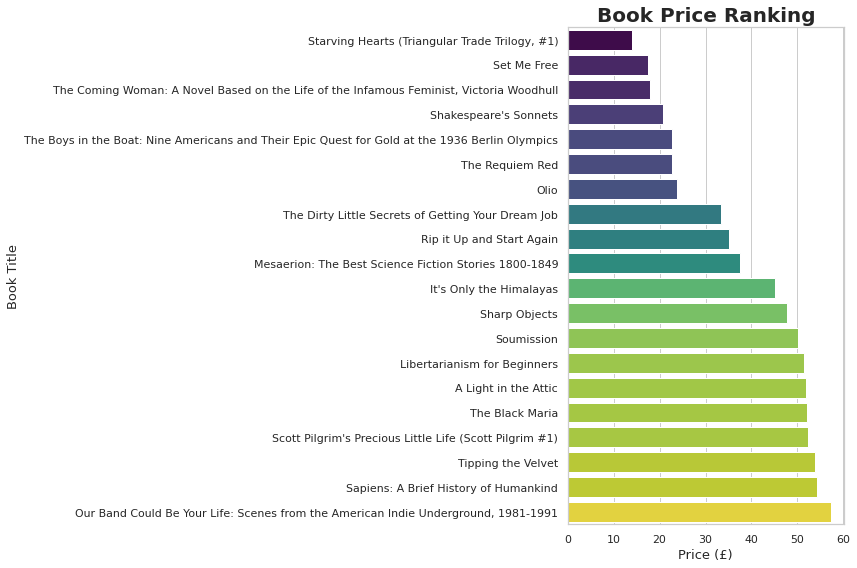

In [8]:
plt.figure(figsize=(12, 8))

price_rank = df.sort_values("Price", ascending=True)

sns.barplot(
    data=price_rank,
    x="Price",
    y="Title",
    hue="Price",
    palette="viridis",
    legend=False
)

plt.title(
    "Book Price Ranking",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Price (£)", fontsize=13)
plt.ylabel("Book Title", fontsize=13)

plt.tight_layout()
plt.show()

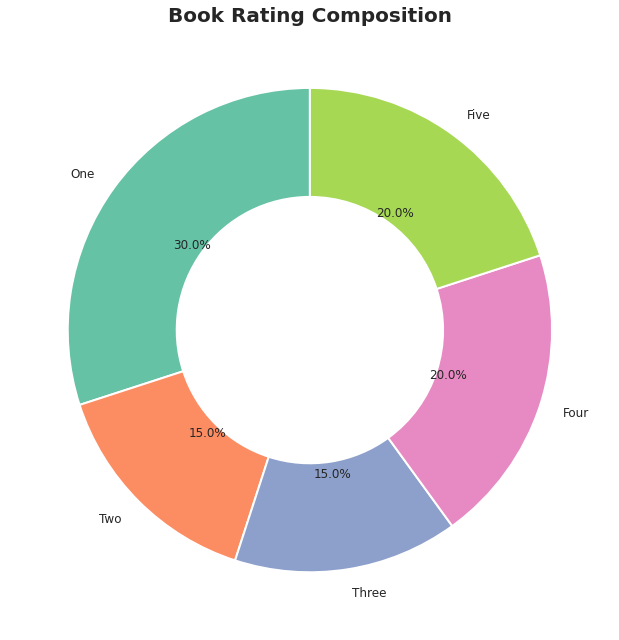

In [9]:
rating_order = ["One", "Two", "Three", "Four", "Five"]

rating_counts = (
    df["Rating"]
    .value_counts()
    .reindex(rating_order, fill_value=0)
)

plt.figure(figsize=(9, 9))

plt.pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", 5),
    wedgeprops={
        "width": 0.45,
        "edgecolor": "white",
        "linewidth": 2
    },
    textprops={
        "fontsize": 12
    }
)

plt.title(
    "Book Rating Composition",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

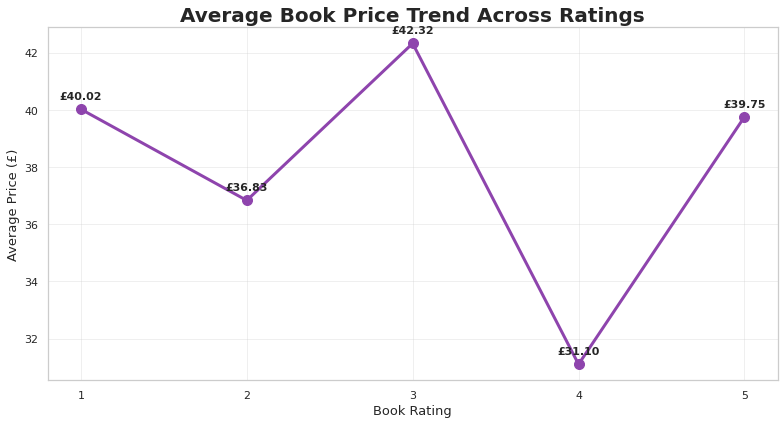

In [10]:
average_price = (
    df.groupby("Rating_Number")["Price"]
    .mean()
    .round(2)
)

plt.figure(figsize=(11, 6))

plt.plot(
    average_price.index,
    average_price.values,
    marker="o",
    markersize=10,
    linewidth=3,
    color="#8E44AD"
)

# Add value labels
for x, y in zip(average_price.index, average_price.values):
    plt.annotate(
        f"£{y:.2f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Average Book Price Trend Across Ratings",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Book Rating", fontsize=13)
plt.ylabel("Average Price (£)", fontsize=13)

plt.xticks([1, 2, 3, 4, 5])

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

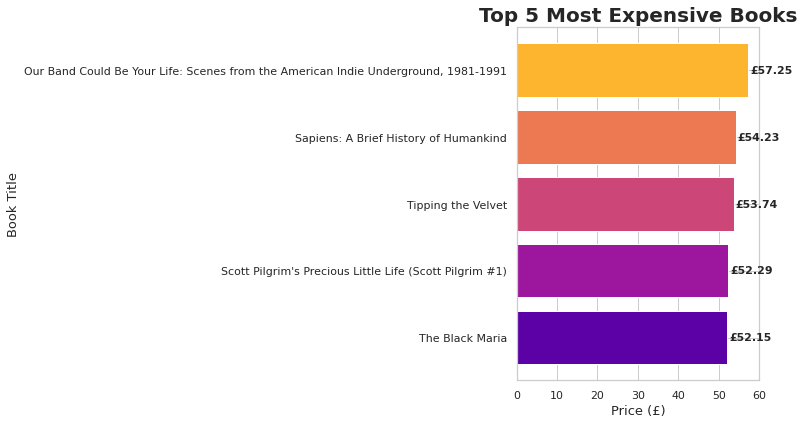

In [11]:
top5 = df.nlargest(5, "Price").sort_values("Price")

plt.figure(figsize=(11, 6))

bars = plt.barh(
    top5["Title"],
    top5["Price"],
    color=sns.color_palette("plasma", 5)
)

for bar, price in zip(bars, top5["Price"]):
    plt.text(
        price + 0.5,
        bar.get_y() + bar.get_height() / 2,
        f"£{price:.2f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

plt.title(
    "Top 5 Most Expensive Books",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Price (£)", fontsize=13)
plt.ylabel("Book Title", fontsize=13)

plt.tight_layout()
plt.show()

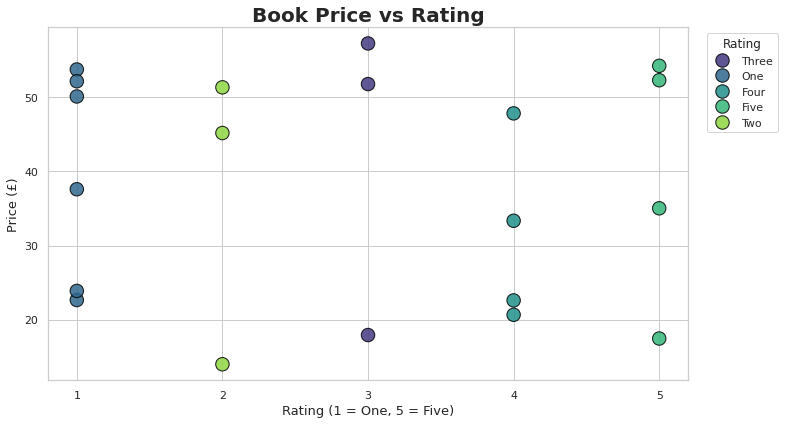

In [12]:
plt.figure(figsize=(11, 6))

sns.scatterplot(
    data=df,
    x="Rating_Number",
    y="Price",
    hue="Rating",
    palette="viridis",
    s=180,
    alpha=0.85,
    edgecolor="black"
)

plt.title(
    "Book Price vs Rating",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Rating (1 = One, 5 = Five)", fontsize=13)
plt.ylabel("Price (£)", fontsize=13)

plt.xticks([1, 2, 3, 4, 5])

plt.legend(
    title="Rating",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

/tmp/ipykernel_20031/364523947.py:80: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/lib/python3/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


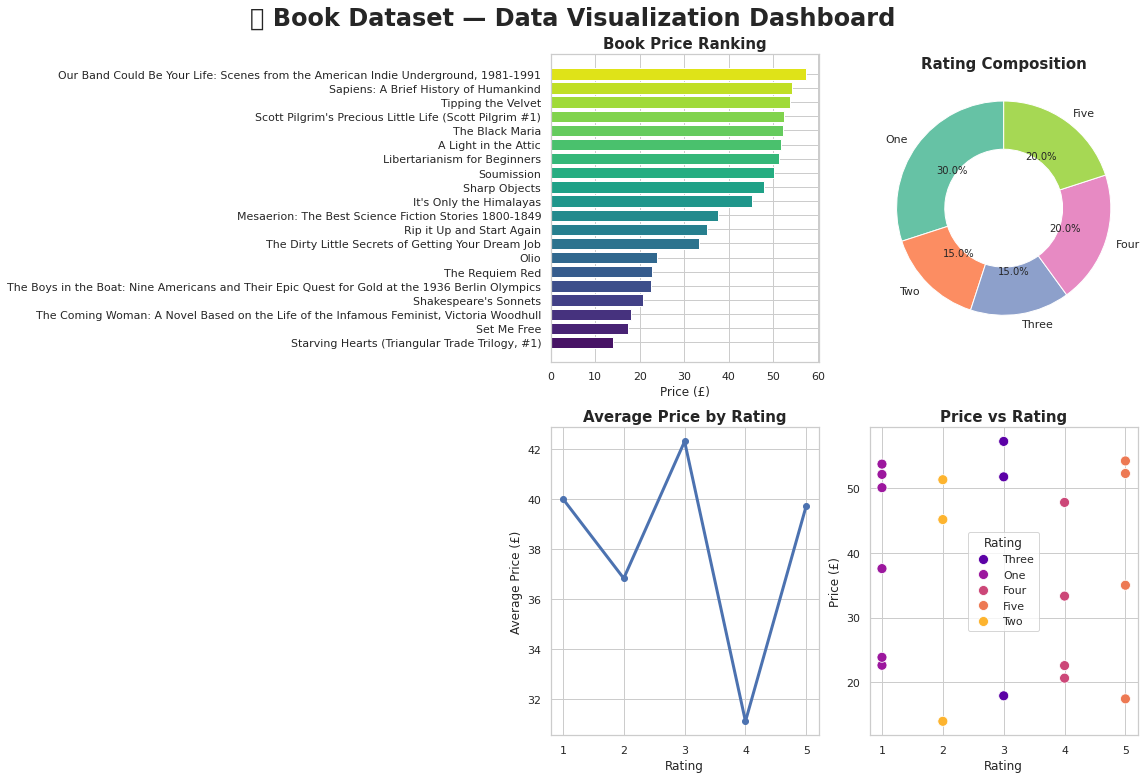

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Price ranking
price_rank = df.sort_values("Price", ascending=True)

axes[0, 0].barh(
    price_rank["Title"],
    price_rank["Price"],
    color=sns.color_palette("viridis", len(price_rank))
)

axes[0, 0].set_title(
    "Book Price Ranking",
    fontsize=15,
    fontweight="bold"
)

axes[0, 0].set_xlabel("Price (£)")

# 2. Rating composition
axes[0, 1].pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=sns.color_palette("Set2", 5),
    wedgeprops={"width": 0.45}
)

axes[0, 1].set_title(
    "Rating Composition",
    fontsize=15,
    fontweight="bold"
)

# 3. Average price trend
axes[1, 0].plot(
    average_price.index,
    average_price.values,
    marker="o",
    linewidth=3
)

axes[1, 0].set_title(
    "Average Price by Rating",
    fontsize=15,
    fontweight="bold"
)

axes[1, 0].set_xlabel("Rating")
axes[1, 0].set_ylabel("Average Price (£)")
axes[1, 0].set_xticks([1, 2, 3, 4, 5])

# 4. Price vs rating
sns.scatterplot(
    data=df,
    x="Rating_Number",
    y="Price",
    hue="Rating",
    palette="plasma",
    s=100,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Price vs Rating",
    fontsize=15,
    fontweight="bold"
)

axes[1, 1].set_xlabel("Rating")
axes[1, 1].set_ylabel("Price (£)")

fig.suptitle(
    "📚 Book Dataset — Data Visualization Dashboard",
    fontsize=24,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# 📌 Conclusion

The Data Visualization task transformed the raw book dataset into
clear, interactive, and visually appealing charts using Python,
Pandas, Matplotlib, and Seaborn.

The visualizations helped identify important patterns in book prices,
ratings, and their relationships. The price ranking chart highlighted
the most expensive books, while the rating composition chart showed
the distribution of ratings across the dataset.

The average price trend provided a visual comparison of prices across
different ratings, and the price-versus-rating chart helped examine
whether higher-rated books tend to have higher prices.

The dashboard combined multiple visualizations into a single view,
making the information easier to understand and communicate.

Overall, the project demonstrates how effective data visualization can
transform raw data into meaningful insights and support better
data-driven understanding and decision-making.